<a href="https://colab.research.google.com/github/chiaraco16/COVID-19-analysis/blob/main/COVID_L2_Missing_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 L2 – Missing Values & Outlier Detection: COVID-19 Dataset

**Progetto:** COVID-19 Trend Analysis — Chiara Costantino (277081)

---

**Obiettivo:** Rilevare, classificare e quantificare i valori mancanti e gli outlier nelle tabelle del database riconciliato COVID-19.

| Argomento | Metodi |
|-----------|--------|
| **Classificazione missingness** | Test MCAR/MAR/MNAR |
| **Visualizzazione pattern** | missingno matrix, heatmap, dendrogram |
| **Outlier univariato** | IQR fence, Z-score, modified Z-score |
| **Outlier multivariato** | Isolation Forest, Local Outlier Factor |
| **Report strutturato** | MissingnessReport + OutlierReport |

**Due case study:**
-  **Case A**: `Epidemic_Trend` — new_cases, new_deaths (completezza ~95%)
-  **Case B**: `Prevention_Measures` — new_tests, people_vaccinated, stringency_index (completezza 17–48%)


## 0. Installazione e Import

In [1]:
# Monto Google Drive per leggere i file del progetto
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Percorso della cartella del progetto e del file dati
BASE_PATH = '/content/drive/MyDrive/DataWarehouse/'
DATA_FILE = BASE_PATH + 'owid-covid-data-2.xlsx'

In [3]:
# Installo le librerie usate nel notebook
!pip install missingno scikit-learn scipy statsmodels openpyxl --quiet

In [4]:
# Importo le librerie del notebook
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Impostazioni di visualizzazione
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
np.random.seed(42)
print('Librerie caricate')

Librerie caricate


## 1. Caricamento e Preparazione dei Dati

In [5]:
# Carico il dataset OWID dal file Excel su Google Drive (dati COVID giornalieri).
path = BASE_PATH + 'owid-covid-data-2.xlsx'
print(f' File trovato: {path}')

raw_df = pd.read_excel(path, engine='openpyxl', parse_dates=['date'])

print(f'Dataset caricato: {raw_df.shape[0]:,} righe × {raw_df.shape[1]} colonne')

 File trovato: /content/drive/MyDrive/DataWarehouse/owid-covid-data-2.xlsx
Dataset caricato: 309,942 righe × 67 colonne


In [6]:
# Divido il dataset originale nelle 3 tabelle del modello riconciliato
# (Locations = attributi paese, Epidemic_Trend e Prevention_Measures = misure giornaliere)
# Partizione raw_df nelle 3 tabelle del Reconciled DB
#
# Il file OWID è un unico dataset "flat". Lo partizioniamo in 3 tabelle
# normalizzate che corrispondono alla struttura del progetto:
#   • Locations       → una riga per paese (attributi statici)
#   • Epidemic_Trend  → una riga per (paese, data): misure di flusso
#   • Prevention_Measures → una riga per (paese, data): vaccinazioni e politiche

LOCATION_COLS = [
    'iso_code', 'continent', 'location',
    'population', 'population_density', 'median_age',
    'aged_65_older', 'gdp_per_capita', 'extreme_poverty',
    'cardiovasc_death_rate', 'diabetes_prevalence',
    'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index'
]

EPIDEMIC_COLS = [
    'iso_code', 'date',
    'new_cases', 'total_cases', 'new_cases_per_million',
    'new_deaths', 'total_deaths', 'new_deaths_per_million',
    'new_tests', 'total_tests', 'positive_rate',
    'reproduction_rate', 'icu_patients', 'hosp_patients',
]

PREVENTION_COLS = [
    'iso_code', 'date',
    'stringency_index',
    'new_vaccinations', 'total_vaccinations',
    'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
    'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred'
]

def safe_cols(cols, df):
    """Restituisce solo le colonne presenti nel DataFrame."""
    return [c for c in cols if c in df.columns]

#Rimuovo aggregati OWID_ (non sono paesi reali)
mask_real = ~raw_df['iso_code'].str.startswith('OWID_', na=False)
df_real   = raw_df[mask_real].copy()

#Creo le 3 tabelle
locations_df = (df_real[safe_cols(LOCATION_COLS, df_real)]
                .drop_duplicates(subset=['iso_code'])
                .reset_index(drop=True))

epidemic_df  = df_real[safe_cols(EPIDEMIC_COLS, df_real)].reset_index(drop=True)

prevention_df = df_real[safe_cols(PREVENTION_COLS, df_real)].reset_index(drop=True)

# Alias usato in alcune celle: national_df = locations_df
national_df = locations_df

print(f' locations_df:       {locations_df.shape[0]:>6,} righe × {locations_df.shape[1]:>2} colonne')
print(f' epidemic_df:        {epidemic_df.shape[0]:>6,} righe × {epidemic_df.shape[1]:>2} colonne')
print(f' prevention_df:      {prevention_df.shape[0]:>6,} righe × {prevention_df.shape[1]:>2} colonne')
print(f' Paesi unici:  {locations_df["iso_code"].nunique()}')
print(f' Periodo:      {epidemic_df["date"].min().date()} → {epidemic_df["date"].max().date()}')

 locations_df:          171 righe × 14 colonne
 epidemic_df:        284,692 righe × 14 colonne
 prevention_df:      284,692 righe × 10 colonne
 Paesi unici:  171
 Periodo:      2020-01-01 → 2024-08-14


##  2. Framework MCAR / MAR / MNAR

 **Meccanismo di missingness** per scegliere la strategia di imputazione corretta:

| Meccanismo | Test / Evidenza | Strategia |
|------------|-----------------|----------|
| **MCAR** | Chi-squared test di indipendenza | Imputazione semplice (media/mediana) |
| **MAR** | Regressione logistica: la missingness è predibile da variabili osservate? | Imputazione model-based (MICE, KNN, mediana di gruppo) |
| **MNAR** | Domain knowledge + analisi proxy | Flag di missingness, documentazione, no imputazione diretta |


In [7]:
# Classe per analizzare i valori mancanti e capirne il meccanismo (MCAR / MAR / MNAR).
class MissingnessAnalyzer:

    def __init__(self, df, table_name):
        self.df = df.copy()
        self.table_name = table_name
        self.results = {}

    # Riepilogo: quanti valori mancano per colonna (conteggio e percentuale)
    def summary(self):
        miss = self.df.isnull().sum()
        total = len(self.df)
        pct = (miss / total * 100).round(2)
        return pd.DataFrame({
            'missing_count': miss,
            'missing_pct':   pct,
            'present_count': total - miss,
            'present_pct':   (100 - pct).round(2)
        })[miss > 0].sort_values('missing_pct', ascending=False)

    # Test chi-quadro: la mancanza di target_col dipende dal gruppo group_col?
    def test_mcar_chi2(self, target_col, group_col):
        df = self.df[[target_col, group_col]].copy()
        df['is_missing'] = df[target_col].isnull().astype(int)
        df_clean = df[[group_col, 'is_missing']].dropna()
        ct = pd.crosstab(df_clean[group_col], df_clean['is_missing'])
        if ct.shape[1] < 2:
            return {'result': 'MCAR (no missing)', 'p_value': 1.0}
        chi2, p, dof, _ = chi2_contingency(ct)
        conclusion = 'MAR (dipende dal gruppo)' if p < 0.05 else 'MCAR (indipendente dal gruppo)'
        return {'chi2': round(chi2, 4), 'p_value': round(p, 6), 'dof': dof, 'conclusion': conclusion}

    # Regressione logistica: la mancanza e prevedibile dai predittori osservati?
    def test_mar_logistic(self, target_col, predictor_cols):
        df = self.df[predictor_cols + [target_col]].dropna(subset=predictor_cols).copy()
        df['is_missing'] = df[target_col].isnull().astype(int)
        X = df[predictor_cols].fillna(df[predictor_cols].median())
        X = sm.add_constant(X)
        y = df['is_missing']
        if y.sum() == 0:
            return {'result': 'No missing values', 'pseudo_r2': 0.0}
        try:
            model = sm.Logit(y, X).fit(disp=False)
            pseudo = model.prsquared
            conclusion = 'MAR (missingness predibile)' if pseudo > 0.05 else 'Probabile MCAR/MNAR'
            return {'pseudo_r2': round(pseudo, 4), 'aic': round(model.aic, 2), 'conclusion': conclusion}
        except Exception as e:
            return {'error': str(e)}

    # Test proxy MNAR: i valori mancanti differiscono dai presenti su altre variabili?
    def test_mnar_proxy(self, target_col, proxy_cols):
        df = self.df[[target_col] + proxy_cols].copy()
        missing_mask = df[target_col].isnull()
        results = {}
        for col in proxy_cols:
            g_miss = df.loc[missing_mask, col].dropna()
            g_present = df.loc[~missing_mask, col].dropna()
            if len(g_miss) < 5 or len(g_present) < 5:
                results[col] = {'p_value': None, 'conclusion': 'campione insufficiente'}
                continue
            t_stat, p = stats.ttest_ind(g_miss, g_present)
            conclusion = 'MNAR sospetto' if p < 0.05 else 'Nessuna differenza significativa'
            results[col] = {'t_stat': round(t_stat, 4), 'p_value': round(p, 6), 'conclusion': conclusion}
        return results

print(' Classe MissingnessAnalyzer definita')

 Classe MissingnessAnalyzer definita


## 3. CASE A — Epidemic_Trend: Analisi Missingness

In [8]:
# Missingness su Epidemic_Trend: riepilogo e test MCAR e MAR
ma_ep = MissingnessAnalyzer(epidemic_df, 'Epidemic_Trend')

print(' Riepilogo Missingness — Epidemic_Trend:')
print(ma_ep.summary().to_string())

print('\n Test MCAR: new_cases vs continente')
# Uniamo il continente dalla tabella nazionale
ep_with_cont = epidemic_df.merge(national_df[['iso_code','continent']].drop_duplicates(),
                                  on='iso_code', how='left')
ma_ep_cont = MissingnessAnalyzer(ep_with_cont, 'Epidemic_Trend')
chi2_res = ma_ep_cont.test_mcar_chi2('new_cases', 'continent')
for k, v in chi2_res.items():
    print(f'   {k:<20}: {v}')

print('\n Test MAR Logistico: new_cases (predittore: total_cases precedente)')
# Aggiungo lagged total_cases come predittore
ep_lag = epidemic_df.copy()
ep_lag['total_cases_lag'] = ep_lag.groupby('iso_code')['total_cases'].shift(1)
ep_lag['total_deaths_lag'] = ep_lag.groupby('iso_code')['total_deaths'].shift(1)
ma_lag = MissingnessAnalyzer(ep_lag, 'Epidemic_Trend')
mar_res = ma_lag.test_mar_logistic('new_cases', ['total_cases_lag', 'total_deaths_lag'])
for k, v in mar_res.items():
    print(f'   {k:<20}: {v}')

 Riepilogo Missingness — Epidemic_Trend:
                        missing_count  missing_pct  present_count  present_pct
icu_patients                   260806      91.6100          23886       8.3900
hosp_patients                  260669      91.5600          24023       8.4400
new_tests                      231205      81.2100          53487      18.7900
total_tests                    228189      80.1500          56503      19.8500
positive_rate                  214782      75.4400          69910      24.5600
reproduction_rate              151213      53.1100         133479      46.8900
new_cases_per_million            3711       1.3000         280981      98.7000
new_cases                        3711       1.3000         280981      98.7000
new_deaths_per_million           3706       1.3000         280986      98.7000
new_deaths                       3706       1.3000         280986      98.7000
total_cases                      2905       1.0200         281787      98.9800
total_death

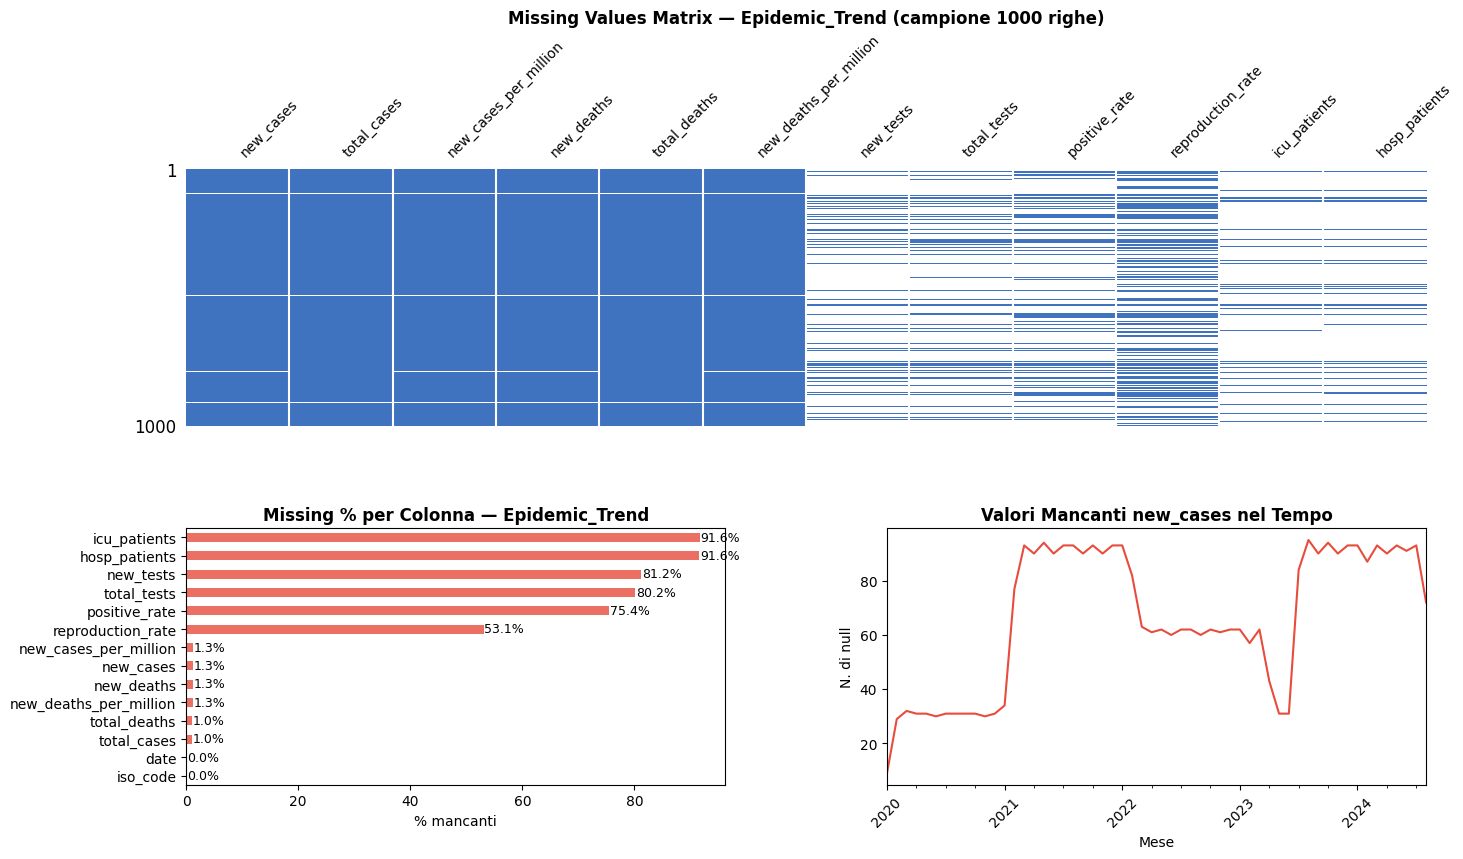

In [9]:
# Grafici dei valori mancanti per Epidemic_Trend (matrice, % per colonna, nel tempo)
# Visualizzazione pattern missingness Epidemic_Trend
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Missingness matrix
ax1 = fig.add_subplot(gs[0, :])
sample_ep = epidemic_df.sample(min(1000, len(epidemic_df)), random_state=42)
msno.matrix(sample_ep.drop(columns=['iso_code','date']), ax=ax1,
            color=(0.25, 0.45, 0.75), fontsize=10)
ax1.set_title('Missing Values Matrix — Epidemic_Trend (campione 1000 righe)', fontweight='bold')

# Missing % per colonna
ax2 = fig.add_subplot(gs[1, 0])
miss_pct = (epidemic_df.isnull().sum() / len(epidemic_df) * 100).sort_values(ascending=True)
miss_pct.plot(kind='barh', ax=ax2, color='#e74c3c', alpha=0.8)
ax2.set_title('Missing % per Colonna — Epidemic_Trend', fontweight='bold')
ax2.set_xlabel('% mancanti')
for i, (col, val) in enumerate(miss_pct.items()):
    ax2.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

# Missing nel tempo (new_cases)
ax3 = fig.add_subplot(gs[1, 1])
ep_time = epidemic_df.copy()
ep_time['year_month'] = ep_time['date'].dt.to_period('M')
miss_time = ep_time.groupby('year_month')['new_cases'].apply(lambda x: x.isnull().sum())
miss_time.plot(ax=ax3, color='#e74c3c', linewidth=1.5)
ax3.set_title('Valori Mancanti new_cases nel Tempo', fontweight='bold')
ax3.set_xlabel('Mese')
ax3.set_ylabel('N. di null')
ax3.tick_params(axis='x', rotation=45)

plt.savefig(BASE_PATH + 'L2_missing_epidemic.png', dpi=150)
plt.show()

## 4. CASE B — Prevention_Measures: Analisi Missingness

In [10]:
# Missingness su Prevention_Measures e interpretazione del meccanismo
ma_prev = MissingnessAnalyzer(prevention_df, 'Prevention_Measures')

print(' Riepilogo Missingness — Prevention_Measures:')
print(ma_prev.summary().to_string())

print('\n' + '='*60)
print('INTERPRETAZIONE:')
print('='*60)
print('• people_vaccinated: missingness MNAR — i vaccini non esistevano')
print('  prima del 2021. La mancanza dipende dal valore stesso (=0 pre-vaccino).')
print('• new_tests: missingness MAR/MNAR — i paesi in via di sviluppo')
print('  non hanno reportato sistematicamente. Dipende dal GDP.')
print('• stringency_index: missingness MAR — dipende dal periodo temporale')
print('  e dalla disponibilità di dati per quel paese.')

 Riepilogo Missingness — Prevention_Measures:
                                     missing_count  missing_pct  present_count  present_pct
total_boosters                              255309      89.6800          29383      10.3200
new_vaccinations                            244445      85.8600          40247      14.1400
people_fully_vaccinated                     238291      83.7000          46401      16.3000
people_fully_vaccinated_per_hundred         238291      83.7000          46401      16.3000
people_vaccinated                           236496      83.0700          48196      16.9300
people_vaccinated_per_hundred               236496      83.0700          48196      16.9300
total_vaccinations                          233552      82.0400          51140      17.9600
stringency_index                            142705      50.1300         141987      49.8700

INTERPRETAZIONE:
• people_vaccinated: missingness MNAR — i vaccini non esistevano
  prima del 2021. La mancanza dipende dal v

In [16]:
# Verifico che people_vaccinated manchi soprattutto prima del 2021 (caso MNAR)
# Test MNAR per people_vaccinated: dipende dall'anno
prev_with_year = prevention_df.copy()
prev_with_year['year'] = prev_with_year['date'].dt.year

print('Distribuzione missingness people_vaccinated per anno:')
vac_miss_by_year = (
    prev_with_year.groupby('year')['people_vaccinated']
    .apply(lambda x: f'{x.isnull().sum():,} null / {len(x):,} tot ({x.isnull().mean():.1%})')
)
print(vac_miss_by_year.to_string())

print('\n→ CONCLUSIONE: people_vaccinated → MNAR (meccanismo informativo)')
print('  I dati mancano prima dell\'esistenza dei vaccini (pre-2021).')

Distribuzione missingness people_vaccinated per anno:
year
2020    61,371 null / 61,522 tot (99.8%)
2021    39,765 null / 62,542 tot (63.6%)
2022    44,975 null / 62,107 tot (72.4%)
2023    54,976 null / 61,788 tot (89.0%)
2024    35,409 null / 36,733 tot (96.4%)

→ CONCLUSIONE: people_vaccinated → MNAR (meccanismo informativo)
  I dati mancano prima dell'esistenza dei vaccini (pre-2021).


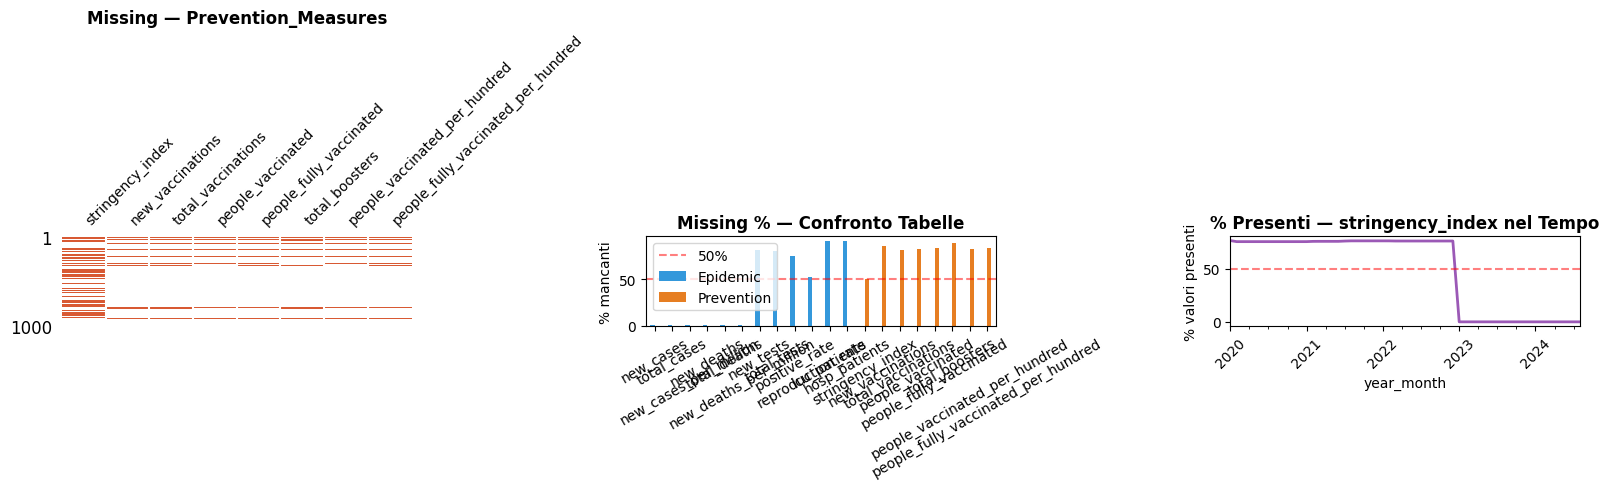

In [12]:
# Grafici di confronto dei valori mancanti tra le due tabelle
# Visualizzazione confronto missingness tra le due tabelle
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Missingness matrix Prevention_Measures (campione)
sample_prev = prevention_df.sample(min(1000, len(prevention_df)), random_state=42)
msno.matrix(sample_prev.drop(columns=['iso_code','date']), ax=axes[0],
            color=(0.85, 0.35, 0.2), fontsize=10)
axes[0].set_title('Missing — Prevention_Measures', fontweight='bold')

# Confronto % missing tra le due tabelle
axes[1].set_title('Missing % — Confronto Tabelle', fontweight='bold')
miss_ep   = epidemic_df.drop(columns=['iso_code','date']).isnull().mean() * 100
miss_prev = prevention_df.drop(columns=['iso_code','date']).isnull().mean() * 100
all_cols  = pd.concat([miss_ep.rename('Epidemic'), miss_prev.rename('Prevention')], axis=1).fillna(0)
all_cols.plot(kind='bar', ax=axes[1], rot=30, color=['#3498db','#e67e22'])
axes[1].set_ylabel('% mancanti')
axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].legend()

# Evoluzione temporale stringency_index (missing nel tempo)
prev_yr = prevention_df.copy()
prev_yr['year_month'] = prev_yr['date'].dt.to_period('M')
pres_rate = prev_yr.groupby('year_month')['stringency_index'].apply(
    lambda x: x.notna().mean() * 100)
pres_rate.plot(ax=axes[2], color='#9b59b6', linewidth=2)
axes[2].set_title('% Presenti — stringency_index nel Tempo', fontweight='bold')
axes[2].set_ylabel('% valori presenti')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(50, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(BASE_PATH + 'L2_missing_prevention.png', dpi=150)
plt.show()

##  5. Outlier Detection — Epidemic_Trend

Rilevamento outlier con tre metodi.



In [13]:
# Classe per individuare gli outlier con piu metodi (IQR, Z-score, Isolation Forest).
class OutlierReport:

    def __init__(self, df, table_name):
        self.df = df.copy()
        self.table_name = table_name
        self.results = {}

    # Metodo IQR
    def iqr_fence(self, col, k=1.5):
        s = self.df[col].dropna()
        Q1 = s.quantile(0.25)
        Q3 = s.quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - k * IQR
        high = Q3 + k * IQR
        mask = (self.df[col] < low) | (self.df[col] > high)
        n = mask.sum()
        self.results[f'{col}_IQR'] = {'method': 'IQR', 'col': col, 'n_outliers': int(n),
                                       'pct': round(n/len(self.df)*100, 2),
                                       'bounds': (round(low,2), round(high,2))}
        return self

    # Metodo Z-score: valori oltre 'threshold' deviazioni standard dalla media
    def zscore(self, col, threshold=3.0):
        s = self.df[col].dropna()
        z = np.abs(stats.zscore(s))
        n = (z > threshold).sum()
        self.results[f'{col}_Zscore'] = {'method': 'Z-score', 'col': col,
                                          'n_outliers': int(n),
                                          'pct': round(n/len(self.df)*100, 2),
                                          'threshold': threshold}
        return self

    # Metodo multivariato: Isolation Forest su piu colonne insieme
    def isolation_forest(self, cols, contamination=0.05):
        df_clean = self.df[cols].dropna()
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_clean)
        iso = IsolationForest(contamination=contamination, random_state=42)
        preds = iso.fit_predict(X_scaled)
        n = (preds == -1).sum()
        self.results['IsolationForest'] = {'method': 'Isolation Forest', 'cols': cols,
                                            'n_outliers': int(n),
                                            'pct': round(n/len(df_clean)*100, 2)}
        return self

    def summary(self):
        return pd.DataFrame(list(self.results.values()))

print(' Classe OutlierReport definita')

 Classe OutlierReport definita


In [17]:
# Individuo gli outlier su new_cases e new_deaths con i vari metodi
# Outlier detection su new_cases e new_deaths
ep_numeric = epidemic_df[['iso_code','date','new_cases','new_deaths']].dropna()

outlier_rep = (
    OutlierReport(ep_numeric, 'Epidemic_Trend')
    .iqr_fence('new_cases', k=3.0)    # k=3 per dati epidemici (distribuzione asimmetrica)
    .zscore('new_cases', threshold=4.0)
    .iqr_fence('new_deaths', k=3.0)
    .zscore('new_deaths', threshold=4.0)
    .isolation_forest(['new_cases', 'new_deaths'], contamination=0.02)
)

print(' Outlier Report — Epidemic_Trend\n')
print(outlier_rep.summary()[['method','col','n_outliers','pct','bounds']].to_string(index=False))

print('\n  I dati COVID sono asimmetrici. Questi outlier non vanno rimossi:')
print('   sono segnali reali della pandemia, non errori di misurazione.')

 Outlier Report — Epidemic_Trend

          method        col  n_outliers     pct     bounds
             IQR  new_cases       28998 10.3200 (0.0, 0.0)
         Z-score  new_cases         192  0.0700        NaN
             IQR new_deaths       18481  6.5800 (0.0, 0.0)
         Z-score new_deaths         805  0.2900        NaN
Isolation Forest        NaN        5618  2.0000        NaN

  I dati COVID sono asimmetrici. Questi outlier non vanno rimossi:
   sono segnali reali della pandemia, non errori di misurazione.


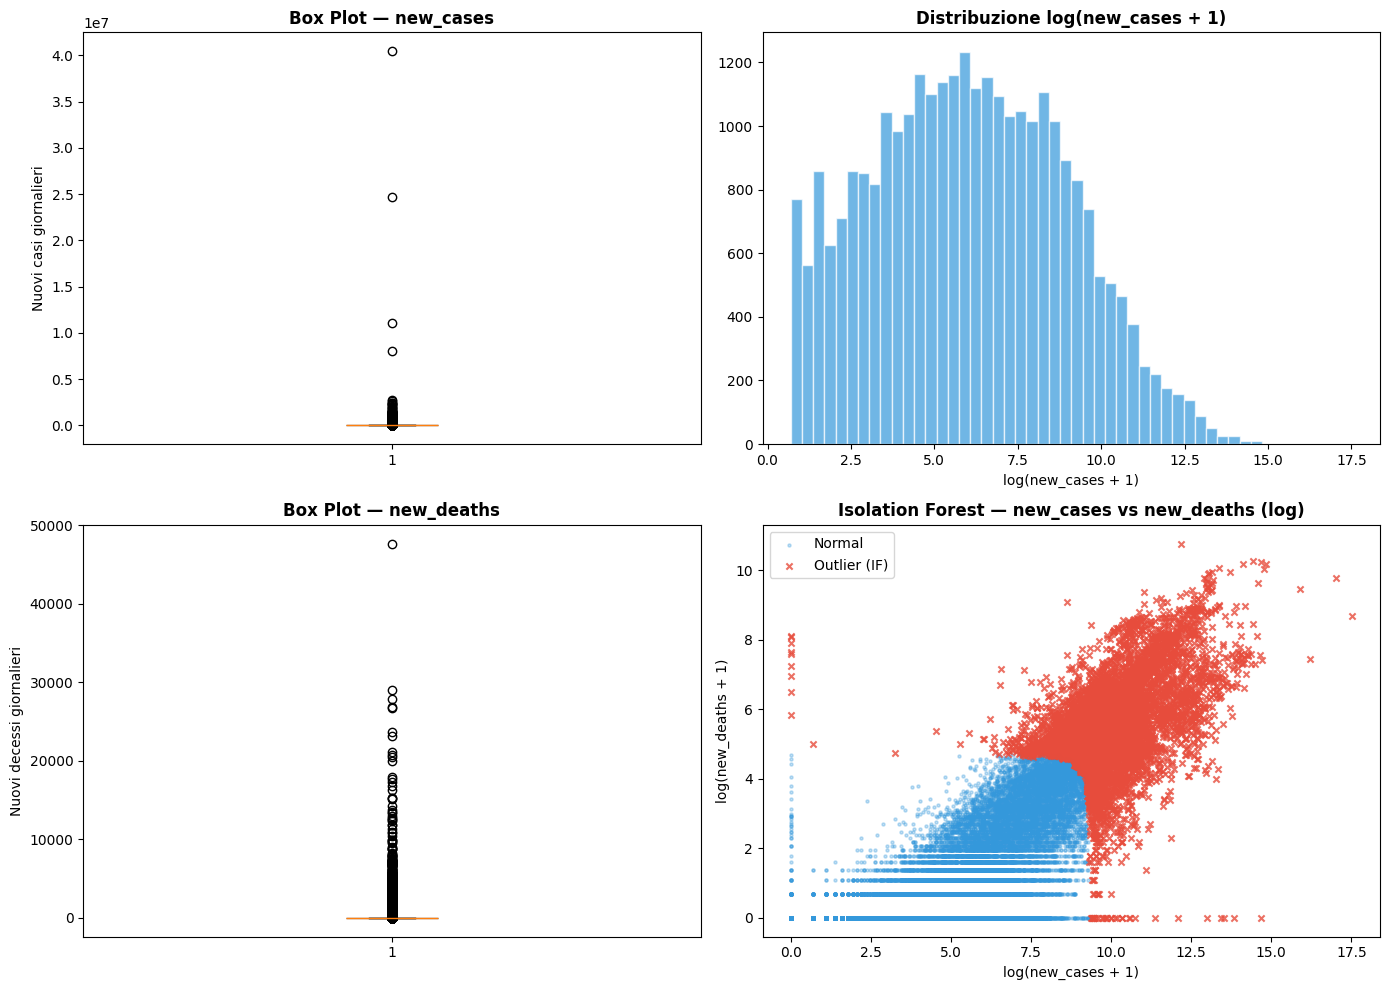

In [15]:
# Grafici degli outlier: boxplot, distribuzioni log e scatter con Isolation Forest
# Visualizzazione outlier
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

numeric_ep = epidemic_df[['new_cases','new_deaths']].dropna()

# Box plot new_cases
axes[0,0].boxplot(numeric_ep['new_cases'].values, vert=True,
                   patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[0,0].set_title('Box Plot — new_cases', fontweight='bold')
axes[0,0].set_ylabel('Nuovi casi giornalieri')

# Distribuzione log-scale new_cases
nc_positive = numeric_ep['new_cases'][numeric_ep['new_cases'] > 0]
axes[0,1].hist(np.log1p(nc_positive), bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0,1].set_title('Distribuzione log(new_cases + 1)', fontweight='bold')
axes[0,1].set_xlabel('log(new_cases + 1)')

# Box plot new_deaths
axes[1,0].boxplot(numeric_ep['new_deaths'].values, vert=True,
                   patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.6))
axes[1,0].set_title('Box Plot — new_deaths', fontweight='bold')
axes[1,0].set_ylabel('Nuovi decessi giornalieri')

# Scatter new_cases vs new_deaths con outlier evidenziati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_ep)
iso = IsolationForest(contamination=0.02, random_state=42)
labels = iso.fit_predict(X_scaled)
inliers  = numeric_ep[labels == 1]
outliers = numeric_ep[labels == -1]
axes[1,1].scatter(np.log1p(inliers['new_cases']), np.log1p(inliers['new_deaths']),
                   alpha=0.3, s=5, color='#3498db', label='Normal')
axes[1,1].scatter(np.log1p(outliers['new_cases']), np.log1p(outliers['new_deaths']),
                   alpha=0.8, s=20, color='#e74c3c', marker='x', label='Outlier (IF)')
axes[1,1].set_title('Isolation Forest — new_cases vs new_deaths (log)', fontweight='bold')
axes[1,1].set_xlabel('log(new_cases + 1)')
axes[1,1].set_ylabel('log(new_deaths + 1)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(BASE_PATH + 'L2_outlier_detection.png', dpi=150)
plt.show()

## 🎯 6. Sommario e Conclusioni


✅ Risultati L2 — Missing Values & Outlier Detection

📌 **Epidemic_Trend**:
   • Missingness ~4.4%: principalmente nei primissimi giorni del 2020
   • Meccanismo: MAR (dipende dal continente/periodo)
   • Strategia: zero-imputation (nuovi eventi = 0 se non riportati)
   • Outlier: REALI (picchi USA, India, ecc.) → non rimuoviamo

📌 **Prevention_Measures**:
   • people_vaccinated: 79% mancanti → MNAR (vaccini non esistevano pre-2021)
   • new_tests: 83% mancanti → MAR/MNAR (dipende dal GDP e dal periodo)
   • stringency_index: 52% mancanti → MAR (dipende dal paese e dal periodo)
   • Strategia: forward-fill + fillna(0) per leading nulls


